# Imports 

In [1]:
import pandas as pd
from collections import defaultdict
import sys
import os
import shutil as sh
import urllib
import tarfile
import numpy as np
import math
import seaborn as sns
import glob, os
import importlib
import gzip
import MDAnalysis as mda
import nglview as nv
import requests
import json
from biopandas.pdb import PandasPdb
from Bio import AlignIO
import re
from io import StringIO
import itertools

from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score

from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import ConvexHull

from urllib.error import HTTPError
from pathlib import Path
from ipywidgets import interact, interactive, fixed, interact_manual, IntProgress
import ipywidgets as widgets # type: ignore
from IPython.display import display, Markdown, clear_output

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [4]:
from functions import IBSClassifier
clf = IBSClassifier(encoding='label', scale=True)

# Methods

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.feature_selection import r_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import matthews_corrcoef
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder



def load_data(path):
    """
    Load data from the path were it was stored.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"The file at {path} was not found.")
    return pd.read_csv(path)

def preprocess_data(df, columns_to_drop=[], categorical_cols=[]):
    """
    Drop uneccessary columns, 
    Encode categorical features, 
    Handle missing values
    """
    encodings: dict[str, np.ndarray] = {}

    # Drop unwanted columns
    if columns_to_drop:
        drop_list = [c for c in columns_to_drop if c in df.columns]
        df = df.drop(columns=drop_list)

    # Label‐encode only the columns listed in categorical_cols
    if categorical_cols:
        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encodings[col] = le.classes_.copy()
                

    # Identify numeric columns and build the pipeline
    num_list = df.select_dtypes(include=[np.number]).columns.tolist()

    num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='mean'))])
    df[num_list] = num_pipeline.fit_transform(df[num_list])

    return df, encodings

def separate_features_target(df, target, columns_to_remove=None):
    if columns_to_remove is None:
        columns_to_remove=[]
    columns_to_remove=set(columns_to_remove + [target])
    X=df.drop(columns=[col for col in columns_to_remove if col in df.columns])
    y=df[target]
    return X, y


def select_features(X, y, threshold=0.1):
    correlations = pd.Series(r_regression(X, y), index=X.columns)
    selected_features = correlations[correlations.abs() >= threshold].index.tolist()
    print(f"The selected features of {X.shape[1]} were: {len(selected_features)}")
    return selected_features, correlations

def train_tuned_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    cmap="Blues",
    scale=True
):
    """
    Train and evaluate a tuned model using:
      - Confusion matrix (plotted as heatmap)
      - AUC (if applicable)
      - Matthews Correlation Coefficient (MCC)

    Returns:
      auc (float or None), mcc (float), y_test, y_pred
    """
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: 0", "Actual: 1"],
        columns=["Predicted: 0", "Predicted: 1"]
    )
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap=cmap)
    plt.title(f"{model.__class__.__name__} Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

    auc = None
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X_test)[:,1]
            auc = roc_auc_score(y_test, y_prob)
            print(f"AUC: {auc:.4f}")
        except Exception:
            print("AUC could not be computed from probabilities.")
    else:
        try:
            auc = roc_auc_score(y_test, y_pred)
            print(f"AUC (label‐based): {auc:.4f}")
        except ValueError:
            print("AUC could not be computed (only one class predicted).")

    
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    return auc, mcc, y_test, y_pred

## Download complete dataset with all anotation at residue-level

In [6]:
import zipfile
import os

zip_path = "/home/user_stel/AISB/Project/Ressources/datasets/S2 File.csv.zip"
# Remove the “.zip” to get the output directory name
extract_dir = zip_path[:-4]

# Make sure the target folder exists (or create it)
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
except zipfile.BadZipFile:
    print("⚠️ Warning: BadZipFile raised – the .zip may be corrupted.")
except Exception as e:
    print(f"⚠️ Warning: {e}")

print("✅ Extracted all files into:", extract_dir)


✅ Extracted all files into: /home/user_stel/AISB/Project/Ressources/datasets/S2 File.csv


In [7]:
path_to_data = "/home/user_stel/AISB/Project/Ressources/datasets/S2 File.csv/S2 File.csv"
df_pre = clf.load_data(path_to_data)

print(df_pre)

       domain  cathpdb   pdb uniprot_acc  uniprot_id residue_name    IBS  \
0          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
1          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
2          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
3          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
4          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
...       ...      ...   ...         ...         ...          ...    ...   
183885    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183886    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183887    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183888    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183889    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS   True   

       chain_id  residue_number  b_factor  ...  S35    S60      S95  \
0             A 

In [8]:
# get column names 
print("Column names:")
for col in df_pre.columns:
    print(col)

Column names:
domain
cathpdb
pdb
uniprot_acc
uniprot_id
residue_name
IBS
chain_id
residue_number
b_factor
sec_struc
sec_struc_full
prot_block
data_type
Experimental Method
resolution
RSA_total_freesasa_tien
convhull_vertex
protrusion
is_hydrophobic_protrusion
is_co_insertable
neighboursList
density
exposed
S35
S60
S95
S100
uniref50
uniref90
uniref100
origin
location
taxon


In [9]:
# get unique domain entries 
unique_domains = df_pre["domain"].unique()
print(unique_domains)

['PH' 'C2' 'START' 'C1' 'C2DIS' 'PX' 'PLD' 'ANNEXIN' 'PLA']


# Data Preprocessing 

In [10]:
# Temporary fix: redefine type to have HIS as polar.
AATYPE = {
    "LEU": "Hydrophobic,H-non-aromatic",
    "ILE": "Hydrophobic,H-non-aromatic",
    "CYS": "Hydrophobic,H-non-aromatic",
    "MET": "Hydrophobic,H-non-aromatic",
    "TYR": "Hydrophobic,H-aromatic",
    "TRP": "Hydrophobic,H-aromatic",
    "PHE": "Hydrophobic,H-aromatic",
    "HIS": "Polar",
    "LYS": "Positive",
    "ARG": "Positive",
    "ASP": "Negative",
    "GLU": "Negative",
    "VAL": "Non-polar",
    "ALA": "Non-polar",
    "SER": "Polar",
    "ASN": "Polar",
    "GLY": "Non-polar",
    "PRO": "Non-polar",
    "GLN": "Polar",
    "THR": "Polar",
    "UNK": "none"
}
df_pre["type"] = df_pre.residue_name.apply(lambda x: AATYPE[x])
print(df_pre)

       domain  cathpdb   pdb uniprot_acc  uniprot_id residue_name    IBS  \
0          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
1          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
2          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
3          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
4          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
...       ...      ...   ...         ...         ...          ...    ...   
183885    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183886    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183887    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183888    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183889    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS   True   

       chain_id  residue_number  b_factor  ...    S60      S95       S100  \
0         

1. **Target column:   IBS**<br>
    false(non-IBS)             → 0<br>
    true(IBS)                  → 1<br>
2. Feature column:  **convhull_vertex**<br>
    false                      → 0<br>
    true                       → 1<br>
3. Feature column:  **protrusion**<br>
    false                      → 0<br>
    true                       → 1<br>
4. Feature column:  **is_hydrophobic_protrusion**<br>
    false                      → 0<br>
    true                       → 1<br>
5. Feature column:  **is_co_insertable** <br>
    false                      → 0<br>
    true                       → 1<br>
6. Feature column:  **exposed**<br>
    false                      → 0<br>
    true                       → 1<br>
7. Feature column:  **type**<br>
    Hydrophobic,H-aromatic     → 0<br>
    Hydrophobic,H-non-aromatic → 1<br>
    Negative                   → 2<br>
    Non-polar                  → 3<br>
    Polar                      → 4<br>
    Positive                   → 5<br>
8. Feature column:  **residue_name**<br>
    0 → ALA<br>
    1 → ARG<br>
    2 → ASN<br>
    3 → ASP<br>
    4 → CYS<br>
    5 → GLN<br>
    6 → GLU<br>
    7 → GLY<br>
    8 → HIS<br>
    9 → ILE<br>
    10 → LEU<br>
    11 → LYS<br>
    12 → MET<br>
    13 → PHE<br>
    14 → PRO<br>
    15 → SER<br>
    16 → THR<br>
    17 → TRP<br>
    18 → TYR<br>
    19 → VAL<br>


In [ ]:
cols_to_drop = ["cathpdb", "pdb", "chain_id", "uniprot_acc", "uniprot_id", "b_factor", "sec_struc", "sec_struc_full", "prot_block", "data_type", 
                "Experimental Method", "resolution", "RSA_total_freesasa_tien", "neighboursList", "density", "S35", "S60", "S95",
                "S100", "uniref50", "uniref90", "uniref100", "origin", "location", "taxon"]
categorical_cols = ["IBS", "residue_name", "convhull_vertex", "protrusion", "is_hydrophobic_protrusion", "is_co_insertable", "exposed", "type"]

df_processed, encodings = clf.preprocess_data(df_pre, columns_to_drop=cols_to_drop, categorical_cols=categorical_cols)

print("Mapping for 'residue_name':")
for code, label in enumerate(encodings["residue_name"]):
    print(f"  {code} → {label}")

Mapping for 'residue_name':
  0 → ALA
  1 → ARG
  2 → ASN
  3 → ASP
  4 → CYS
  5 → GLN
  6 → GLU
  7 → GLY
  8 → HIS
  9 → ILE
  10 → LEU
  11 → LYS
  12 → MET
  13 → PHE
  14 → PRO
  15 → SER
  16 → THR
  17 → TRP
  18 → TYR
  19 → VAL


### Class imbalance & Class Separability 

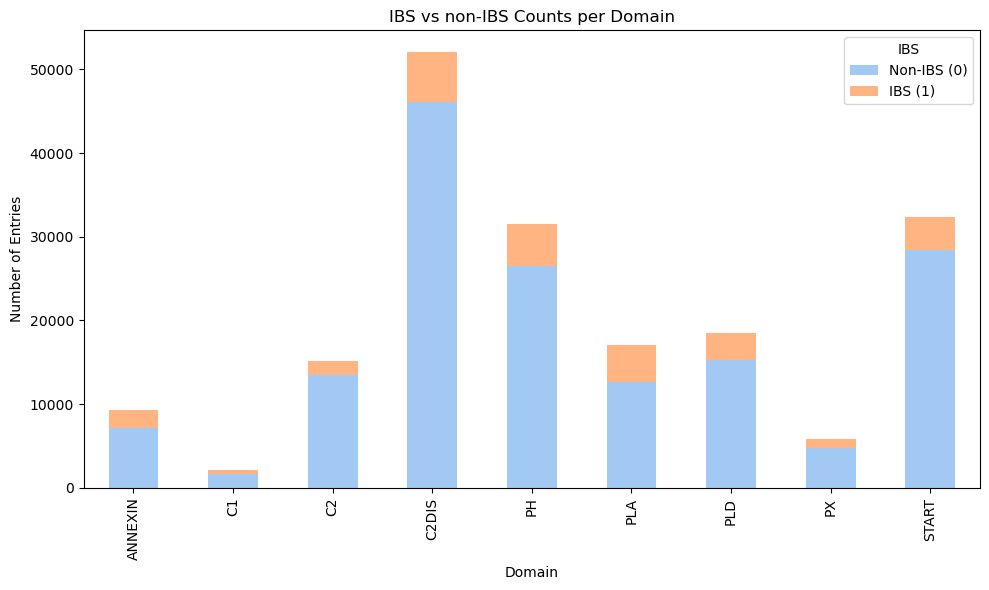

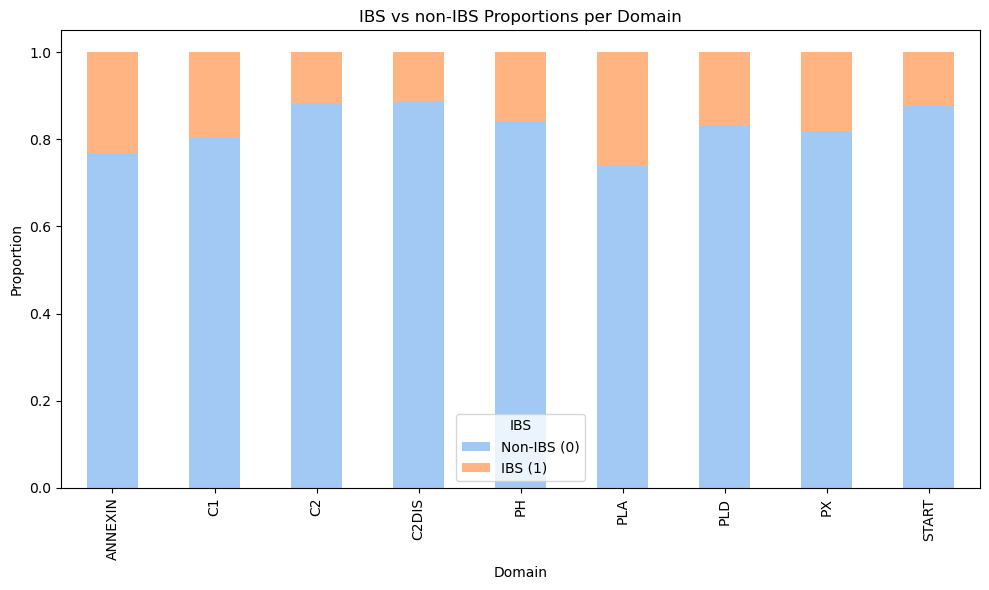

In [ ]:
# this code block can be used in irder to show -for each superfamily- how much of the protein 
# is actually occupied from the interfacial binding sites in comparison to the non-IBS
# plots for each superfamily
# to visualize IBS vs non-IBS (1 vs 0) across 9 unique domains, 
# we group by domain and count the number of IBS (1) and non-IBS (0) entries for each

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by domain and IBS label (0/1)
ibs_counts = df_processed.groupby(['domain', 'IBS']).size().unstack(fill_value=0)

# Bar plot
ibs_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette("pastel", n_colors=2)
)
plt.title("IBS vs non-IBS Counts per Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Entries")
plt.legend(title='IBS', labels=['Non-IBS (0)', 'IBS (1)'])
plt.tight_layout()
plt.show()

# proportions instead of raw counts
ibs_props = ibs_counts.div(ibs_counts.sum(axis=1), axis=0)

# Stacked bar plot of proportions
ibs_props.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette("pastel", n_colors=2)
)
plt.title("IBS vs non-IBS Proportions per Domain")
plt.xlabel("Domain")
plt.ylabel("Proportion")
plt.legend(title='IBS', labels=['Non-IBS (0)', 'IBS (1)'])
plt.tight_layout()
plt.show()


In [14]:
# Count how many residues are labeled as “IBS” vs “non‐IBS”:
df_pre["IBS"].value_counts()

# How many hydrophobic protrusions reside in IBS vs non‐IBS?
df_pre[df_pre["is_hydrophobic_protrusion"] & (df_pre["IBS"] == 1)].shape[0]


1454

## Feature Assessment & Selection

Highly correlated pairs:
convhull_vertex  protrusion    0.836999
dtype: float64
Species to remove: {'protrusion'}
Reduced from 10 to 9 columns.


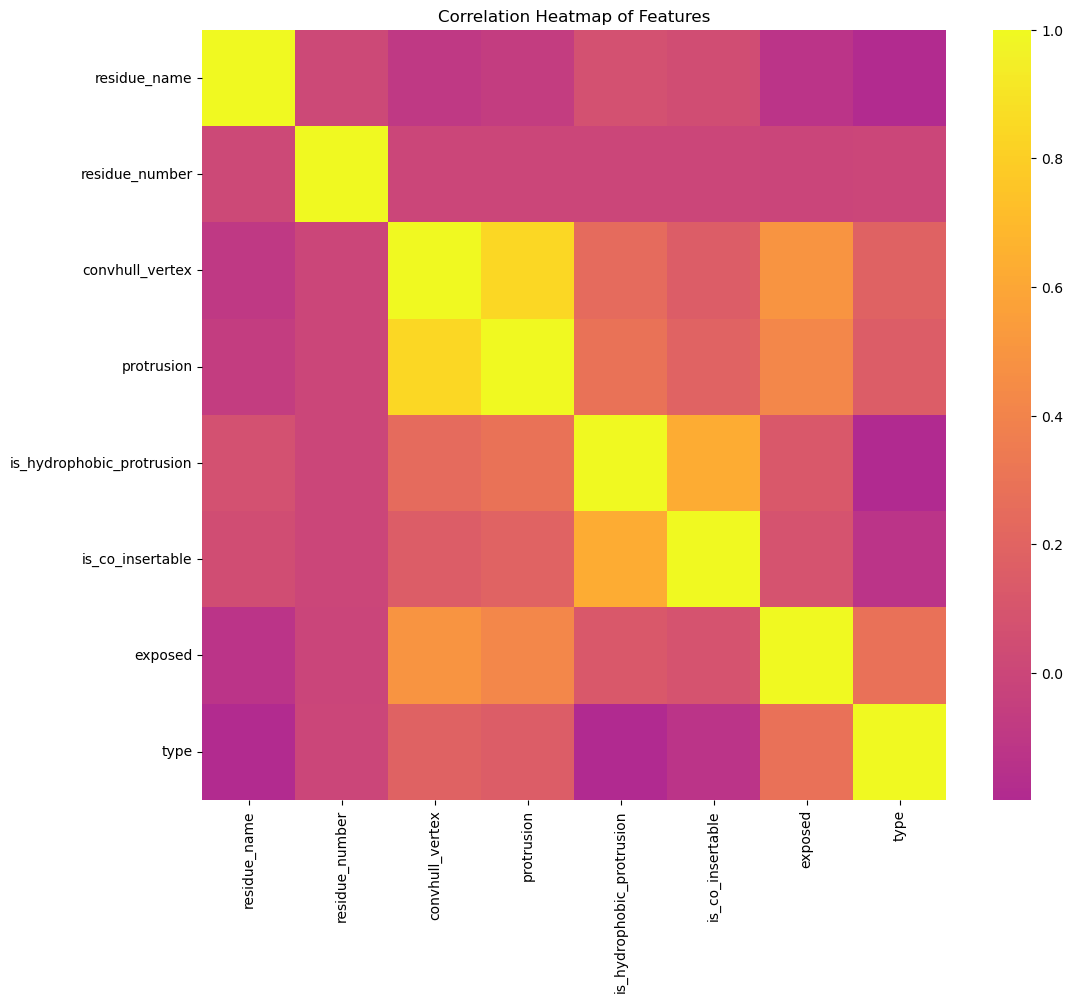

       domain  residue_name  IBS  residue_number  convhull_vertex  \
0          PH           2.0  0.0            19.0              0.0   
1          PH           2.0  0.0            75.0              1.0   
2          PH           2.0  0.0            78.0              1.0   
3          PH           2.0  0.0            92.0              1.0   
4          PH           2.0  0.0            93.0              1.0   
...       ...           ...  ...             ...              ...   
183885    PLA           4.0  0.0            91.0              0.0   
183886    PLA           4.0  0.0            96.0              0.0   
183887    PLA           4.0  0.0            98.0              0.0   
183888    PLA           4.0  0.0           105.0              0.0   
183889    PLA           4.0  1.0           124.0              0.0   

        is_hydrophobic_protrusion  is_co_insertable  exposed  type  
0                             0.0               0.0      1.0   4.0  
1                             0.0

In [ ]:
target = df_processed["IBS"]
features = df_processed.drop(columns=["domain", "IBS"]).columns.tolist()
correlation_matrix=df_processed[features].corr(method='pearson')

threshold = 0.8
high_corr_pairs = (
    correlation_matrix.abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs > threshold]

print("Highly correlated pairs:")
print(high_corr_pairs)

features_to_remove = set()

for pair in high_corr_pairs.index:
    features_to_remove.add(pair[1])

print("Species to remove:", features_to_remove)

# Drop highly correlated features
df_new = df_processed.drop(columns=features_to_remove)
print(f"Reduced from {len(df_processed.columns)} to {len(df_new.columns)} columns.")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='plasma', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()

print(df_new)

In [16]:
# split features and target 
columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(df_new, target='IBS', columns_to_remove=columns_to_remove)

Selected 2 out of 6 features.
['convhull_vertex', 'exposed']
        convhull_vertex  exposed  IBS
0                   0.0      1.0  0.0
1                   1.0      1.0  0.0
2                   1.0      1.0  0.0
3                   1.0      1.0  0.0
4                   1.0      1.0  0.0
...                 ...      ...  ...
183885              0.0      0.0  0.0
183886              0.0      0.0  0.0
183887              0.0      0.0  0.0
183888              0.0      1.0  0.0
183889              0.0      1.0  1.0

[183890 rows x 3 columns]


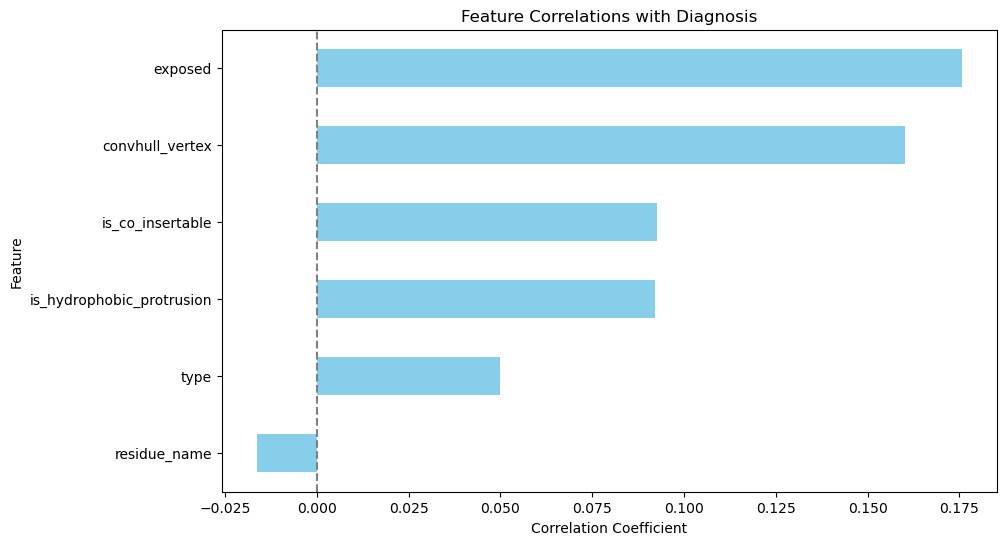

In [17]:
selected_features, correlations= clf.select_features(X, y, threshold=0.1)
                                        
print(selected_features)

# Creates a new dataset that contains only the selected features 
X_selected=X[selected_features]
#print(X_selected)

selected_feature_names = X_selected.columns.tolist()
target = 'IBS'
selected_df = df_new[selected_feature_names + [target]]
print(selected_df)

plt.figure(figsize=(10, 6))
correlations.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Correlations with Diagnosis")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.axvline(0, color='grey', linestyle='--')
plt.show()

### Save preprocessed dataset 

In [18]:
df_new.to_csv("/home/user_stel/AISB/Project/dataset/processed_dataset.csv", index=False)

# Model Analysis

In [12]:
path_to_preprocessed = "/home/user_stel/AISB/Project/dataset/processed_dataset.csv"
df = clf.load_data(path_to_preprocessed)
print(df)

       domain  residue_name  IBS  residue_number  convhull_vertex  \
0          PH           2.0  0.0            19.0              0.0   
1          PH           2.0  0.0            75.0              1.0   
2          PH           2.0  0.0            78.0              1.0   
3          PH           2.0  0.0            92.0              1.0   
4          PH           2.0  0.0            93.0              1.0   
...       ...           ...  ...             ...              ...   
183885    PLA           4.0  0.0            91.0              0.0   
183886    PLA           4.0  0.0            96.0              0.0   
183887    PLA           4.0  0.0            98.0              0.0   
183888    PLA           4.0  0.0           105.0              0.0   
183889    PLA           4.0  1.0           124.0              0.0   

        is_hydrophobic_protrusion  is_co_insertable  exposed  type  
0                             0.0               0.0      1.0   4.0  
1                             0.0

In [23]:
# split features and target 
columns_to_remove = ['domain', 'residue_number']
X, y = clf.separate_features_target(df, target='IBS', columns_to_remove=columns_to_remove)

## Hyperparameter Tuning 

In [ ]:
# # dictionary of hyperparameters
# param_grid = {
#     'LogisticRegression-elasticnet': {
#         'C': [0.01, 0.1, 1, 10],
#         'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
#         'penalty': ['elasticnet'],
#         'solver': ['saga'],
#         'max_iter': [10000]  # Needed for convergence in elasticnet
#     },
#     'RandomForest': {
#         'n_estimators': [100, 200],
#         'max_depth': [None, 10, 20],
#         'min_samples_split': [2, 5],
#         'min_samples_leaf': [1, 2]
#     },
#     'CategoricalNB': {
#         'alpha': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
#     },
#     'XGBoost' : {
#         'n_estimators':    [100, 200],
#         'max_depth':       [3, 6, 9],
#         'learning_rate':   [0.01, 0.1, 0.2],
#         'subsample':       [0.7, 1.0],
#         'colsample_bytree':[0.7, 1.0],
#         'use_label_encoder':[False],      # suppress warning in recent versions
#         'eval_metric':     ['logloss']    # required when use_label_encoder=False
#     }
# }

# # Mapping names to classifier constructors
# models = {
#     'LogisticRegression-elasticnet': LogisticRegression,
#     'RandomForest': RandomForestClassifier,
#     'CategoricalNB': CategoricalNB,
#     'XGBoost': XGBClassifier
# }

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

# # Store all results
# grid_results = {}

# # Loop through each model + param set
# for name, params in param_grid.items():
#     print(f"Running GridSearchCV for {name}...")

#     model = models[name]()  # Create the model
#     clf = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
    
#     clf.fit(X_train, y_train)
    
#     # Save results
#     grid_results[name] = {
#         'best_estimator': clf.best_estimator_,
#         'best_params': clf.best_params_,
#         'best_score': clf.best_score_,
#         'cv_results': clf.cv_results_
#     }

# for name, result in grid_results.items():
#     print(f"===== {name} =====")
#     print("Best params:", result['best_params'])
#     print("Best CV score:", result['best_score'])
#     print("  (click below to see full cv_results_ as a table)")
#     df_cv = pd.DataFrame(result['cv_results'])
#     display(df_cv)    # Collapsible DataFrame for each model
#     print("\n")


In [15]:
param_grid = {
    'LogisticRegression-elasticnet': {
        'C': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'max_iter': [10000]
    },
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'CategoricalNB': {
        'alpha': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.7, 1.0],
        'colsample_bytree': [0.7, 1.0],
        'use_label_encoder': [False],
        'eval_metric': ['logloss']
    }
}

models = {
    'LogisticRegression-elasticnet': LogisticRegression,
    'RandomForest': RandomForestClassifier,
    'CategoricalNB': CategoricalNB,
    'XGBoost': XGBClassifier
}

# Initialize the classifier
clf = IBSClassifier(param_grid=param_grid, model_dict=models)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Run grid search
grid_results = clf.run_grid_search(X_train, y_train)

Running GridSearchCV for LogisticRegression-elasticnet...
Running GridSearchCV for RandomForest...
Running GridSearchCV for CategoricalNB...
Running GridSearchCV for XGBoost...


/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:14:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:14:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:14:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:14:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/pytho


===== LogisticRegression-elasticnet =====
Best params: {'C': 1, 'l1_ratio': 0.0, 'max_iter': 10000, 'penalty': 'elasticnet', 'solver': 'saga'}
Best CV score: 0.8486


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_l1_ratio,param_max_iter,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.540525,0.041077,0.041318,0.010037,0.01,0.00,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.0, 'max_iter': 10000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
1,1.624897,0.110253,0.045556,0.010220,0.01,0.25,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.25, 'max_iter': 1000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
2,1.917984,0.199261,0.019781,0.013964,0.01,0.50,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.5, 'max_iter': 10000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
3,1.790120,0.080631,0.009131,0.001336,0.01,0.75,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.75, 'max_iter': 1000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
4,1.924049,0.044355,0.010377,0.003291,0.01,1.00,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 1.0, 'max_iter': 10000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
5,1.762377,0.097321,0.009250,0.002957,0.10,0.00,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.0, 'max_iter': 10000,...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
6,1.769573,0.127658,0.007801,0.001409,0.10,0.25,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.25, 'max_iter': 10000...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
7,1.942627,0.191069,0.015034,0.003993,0.10,0.50,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 10000,...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
8,2.295290,0.351730,0.017721,0.009112,0.10,0.75,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.75, 'max_iter': 10000...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
9,2.300783,0.404519,0.012572,0.004611,0.10,1.00,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 1.0, 'max_iter': 10000,...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11



===== RandomForest =====
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.8491


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,12.394377,0.596771,0.612427,0.118914,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849680,0.849019,0.84898,0.849208,0.848858,0.849149,0.000288,3
1,26.798640,1.375111,1.152178,0.097586,None,1,2,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848897,0.849095,0.000171,21
2,12.923254,0.817959,0.483716,0.052625,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848897,0.849095,0.000171,21
3,29.212065,3.285142,1.644111,0.336153,None,1,5,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848897,0.849095,0.000171,21
4,15.882079,2.094081,0.693578,0.179252,None,2,2,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848936,0.849102,0.000162,14
5,29.426084,7.148802,1.475055,0.142365,None,2,2,200,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849602,0.849019,0.84898,0.849208,0.848936,0.849149,0.000245,1
6,18.508873,1.225853,0.829426,0.067061,None,2,5,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849369,0.849097,0.84898,0.849208,0.848936,0.849118,0.000157,4
7,28.299014,2.868752,1.543714,0.362612,None,2,5,200,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848936,0.849102,0.000162,14
8,13.317330,1.331936,0.621615,0.167970,10,1,2,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.849446,0.849019,0.84898,0.849208,0.848897,0.849110,0.000197,9
9,28.542226,1.895070,1.251600,0.483775,10,1,2,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.849446,0.849019,0.84898,0.849208,0.848897,0.849110,0.000197,9



===== CategoricalNB =====
Best params: {'alpha': 0.0}
Best CV score: 0.8473


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.048513,0.015553,0.009684,0.003075,0.0,{'alpha': 0.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
1,0.038687,0.004617,0.009835,0.001835,0.1,{'alpha': 0.1},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
2,0.040063,0.005540,0.011577,0.002723,0.5,{'alpha': 0.5},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
3,0.045075,0.007115,0.010832,0.002596,1.0,{'alpha': 1.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
4,0.036398,0.001733,0.008979,0.001706,2.0,{'alpha': 2.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
5,0.038317,0.003142,0.011300,0.001890,5.0,{'alpha': 5.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
6,0.033679,0.003036,0.009114,0.001696,10.0,{'alpha': 10.0},0.847388,0.846922,0.846689,0.84711,0.847227,0.847067,0.000243,7



===== XGBoost =====
Best params: {'colsample_bytree': 0.7, 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7, 'use_label_encoder': False}
Best CV score: 0.8492


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_eval_metric,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,param_use_label_encoder,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.886702,0.076983,0.070253,0.007034,0.7,logloss,0.01,3,100,0.7,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
1,1.602455,0.149051,0.070717,0.009491,0.7,logloss,0.01,3,100,1.0,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
2,2.843697,0.292429,0.114798,0.017437,0.7,logloss,0.01,3,200,0.7,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
3,2.746866,0.137783,0.172384,0.056708,0.7,logloss,0.01,3,200,1.0,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
4,2.307277,0.299002,0.238895,0.061780,0.7,logloss,0.01,6,100,0.7,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,4.634221,0.333779,0.455306,0.084923,1.0,logloss,0.20,6,200,1.0,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849446,0.849019,0.849019,0.849246,0.848897,0.849126,0.000196,15
68,3.354248,0.449519,0.579788,0.127751,1.0,logloss,0.20,9,100,0.7,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849369,0.849019,0.848980,0.849208,0.848858,0.849087,0.000180,46
69,2.311683,0.324542,0.509872,0.145443,1.0,logloss,0.20,9,100,1.0,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849369,0.849019,0.849019,0.849246,0.848897,0.849110,0.000172,26
70,7.404529,0.209259,0.899113,0.171278,1.0,logloss,0.20,9,200,0.7,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849369,0.849019,0.848980,0.849208,0.848858,0.849087,0.000180,46


## Train & Evaluate 


Evaluating best model for: LogisticRegression-elasticnet


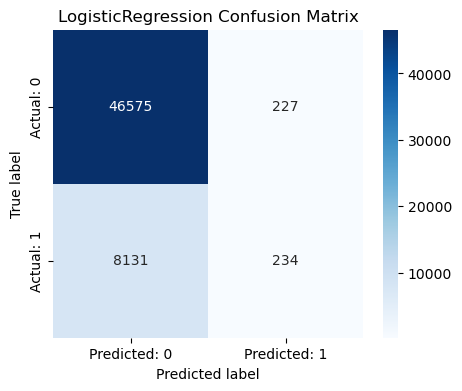

AUC: 0.6543
Matthews Correlation Coefficient (MCC): 0.0911

Evaluating best model for: RandomForest


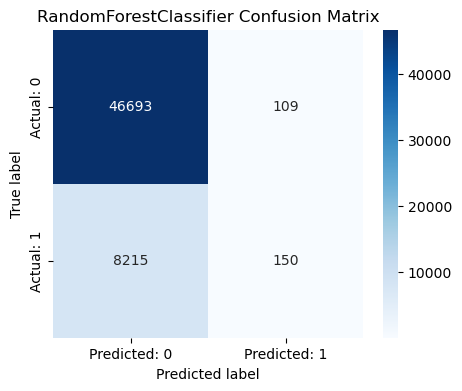

AUC: 0.6842
Matthews Correlation Coefficient (MCC): 0.0819

Evaluating best model for: CategoricalNB


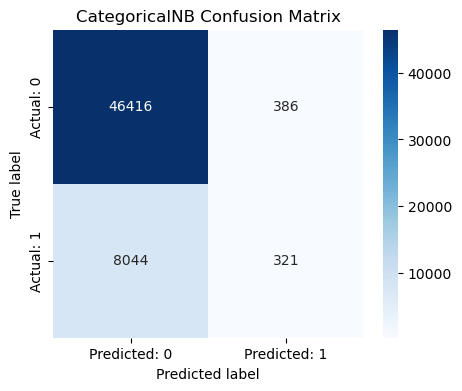

AUC: 0.6734
Matthews Correlation Coefficient (MCC): 0.0961

Evaluating best model for: XGBoost


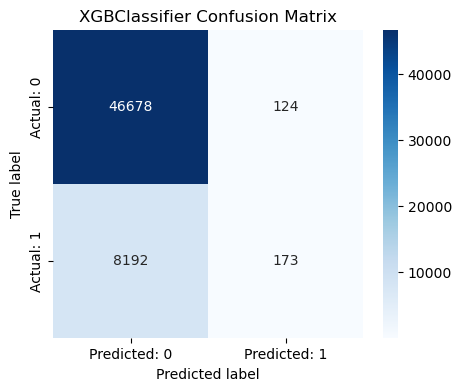

AUC: 0.6825
Matthews Correlation Coefficient (MCC): 0.0884

MCC Summary:
                           Model       MCC
2                  CategoricalNB  0.096066
0  LogisticRegression-elasticnet  0.091107
3                        XGBoost  0.088382
1                   RandomForest  0.081866


In [ ]:
model_mcc_scores = []

for model_name, result in grid_results.items():
    best_model = result['best_estimator']
    print(f"\nEvaluating best model for: {model_name}")
    scale_flag = model_name.startswith("Logistic")
    
    auc, mcc, y_test, y_pred = train_tuned_model(
        best_model, X_train, X_test, y_train, y_test, scale=False
    )
    
    model_mcc_scores.append({
        'Model': model_name,
        'MCC': mcc
    })

# Create DataFrame
mcc_summary_df = pd.DataFrame(model_mcc_scores)
print("\nMCC Summary:")
print(mcc_summary_df.sort_values(by='MCC', ascending=False))

## Build Predicted Dataset

In [24]:
df_test_pred = X_test.copy()

reverse_type = {
     0: "Hydrophobic,H-aromatic",
     1: "Hydrophobic,H-non-aromatic",
     2: "Negative",
     3: "Non-polar",
     4: "Polar",
     5: "Positive"
}

# For the residue_name three‐letter codes:
reverse_residue = {
    0:  "ALA",  1:  "ARG",  2:  "ASN",  3:  "ASP",  4:  "CYS",
    5:  "GLN",  6:  "GLU",  7:  "GLY",  8:  "HIS",  9:  "ILE",
    10: "LEU", 11:  "LYS", 12:  "MET", 13:  "PHE", 14:  "PRO",
    15: "SER", 16:  "THR", 17:  "TRP", 18:  "TYR", 19:  "VAL"
}

df_test_pred['residue_str'] = df_test_pred['residue_name'].map(reverse_residue)
df_test_pred['type_str']    = df_test_pred['type'].map(reverse_type)
df_test_pred['IBS_pred']    = y_pred
df_test_pred['exposed']     = X_test['exposed']   # assuming that’s already boolean/0–1


print(df_test_pred.head())

        residue_name  convhull_vertex  is_hydrophobic_protrusion  \
71217            8.0              1.0                        0.0   
170632          16.0              1.0                        0.0   
55363           10.0              0.0                        0.0   
41382            9.0              0.0                        0.0   
25295           18.0              1.0                        1.0   

        is_co_insertable  exposed  type residue_str  \
71217                0.0      1.0   4.0         HIS   
170632               0.0      1.0   4.0         THR   
55363                0.0      1.0   1.0         LEU   
41382                0.0      0.0   1.0         ILE   
25295                0.0      1.0   0.0         TYR   

                          type_str  IBS_pred  
71217                        Polar         0  
170632                       Polar         0  
55363   Hydrophobic,H-non-aromatic         0  
41382   Hydrophobic,H-non-aromatic         0  
25295       Hydrophobic,H

### Save predicted dataset

In [ ]:
df_test_pred.to_csv("/home/user_stel/AISB/Project/dataset/predicted_dataset.csv", index=False)

## Palette & Configuration

In [6]:
dict_palette_IBS = {"IBS":"#A5CCE2",'nonIBS':"#DFA3AE"}
palette_IBS = [dict_palette_IBS["nonIBS"],dict_palette_IBS["IBS"]]
DPI=300
FORMAT="tif"
sns.set_style("whitegrid") #Seaborn style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams["font.family"] = "Arial" 


def save_fig(figname,folder="article",format="png",dpi=300,bbox_inches='tight', transparent=False, ):
    from pathlib import Path
    Path(f"{FIGURESFOLDER}/{folder}").mkdir(parents=True, exist_ok=True)

    if format in ["tiff",'tif']:
        plt.savefig(f"{FIGURESFOLDER}/{folder}/{figname}.{format}", dpi=dpi, bbox_inches=bbox_inches, transparent=transparent, pil_kwargs={"compression": "tiff_lzw"})
    else:
        plt.savefig(f"{FIGURESFOLDER}/{folder}/{figname}.{format}", dpi=dpi, bbox_inches=bbox_inches, transparent=transparent)

def get_palette_OR(oddsratio):
    palette = []
    for index, row in oddsratio.iterrows():
        if row["pvalue"] < 0.05:
            if row.oddsratio > 0:
                palette.append(dict_palette_IBS["IBS"])
            else:
                palette.append(dict_palette_IBS["nonIBS"])
        else:
            palette.append("gray")
    return(palette)

def significance(ortable):
    def add_symbol(row):
        if row.pvalue > 0.05:
            return "ns"
        elif row.pvalue <= 0.0001:
            return '****'
        elif row.pvalue <= 0.001:
            return '***'
        elif row.pvalue <= 0.01:
            return '**'
        elif row.pvalue <= 0.05:
            return '*'
        else:
            return 'NA'
        
    ortable["significance"] = ortable.apply(lambda x: add_symbol(x), axis=1)
    ortable["labels"] ="("+ortable["significance"]+") " + ortable.iloc[:,0].astype(str)
    return ortable

def equality_test(pop1,pop2, ALTERNATIVE="two-sided", pairwised=False, silent=False, returnPval=False):
    """
    Perform equality test between two sample
    
    Args:
        - pop1 (array): sample1 (continuous or discrete data)
        - pop2 (array): sample2 (continuous or discrete data)
        - ALTERNATIVE (str): could be 'two-sided','less','greater'. Default is 'two-sided'
    Teturn:
        None
    """
        
    #for formating
    from IPython.display import Markdown, display
    def printmd(string, color=None):
        colorstr = "<span style='color:{}'>{}</span>".format(color, string)
        if not silent:
            display(Markdown(colorstr))
        
    printmd("**STATISTICAL TEST BETWEEN TWO SAMPLES**")
    
    printmd(f" - ALTERNATIVE HYPOTHESIS = {ALTERNATIVE}")
    from decimal import Decimal
    import scipy.stats as stats
    
    sign = {"two-sided":"≠",
       "less":"<",
       "greater":">"}
    

    printmd("**NORMALITY TEST (shapiro)**")
    normality = True
    printmd("*The two samples should follow a normal law to use a standard t.test*")

    normpop1 = stats.shapiro(pop1).pvalue
    normpop2 = stats.shapiro(pop2).pvalue
    if normpop1 < 0.05:
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop1:.2E}, <= 0.05. This sample DO NOT follow a normal law", color='red')
        normality = False
    else: 
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop1:.2E}, > 0.05. This sample follow a normal law", color='blue')
    if normpop2 < 0.05:
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop2:.2E}, <= 0.05. This sample DO NOT follow a normal law", color='red')
        normality = False
    else: 
        printmd(f"---- Sample 1 shapioro test pvalue = {normpop2:.2E}, > 0.05. This sample follow a normal law", color='blue')

    if normality == True:
        printmd("Both samples follow a normal law")

        if pairwised == True:
            printmd("**TTest_REL Pairwise test **")
            equalstat, equalpval = stats.ttest_rel(pop1,pop2)
            if returnPval:
                return equalpval
        else: 
            printmd("Performing Variance equality test")
            varstat, varpval = stats.levene(pop1,pop2)
            #Levene, pval < 0.05 --> Variance are not equal.
            #Levene, pval > 0.05 --> Non significatif and the hypothesis H0 is not rejected. 


            printmd("-- Null hypothesis, the the variances are equals")
            printmd(f"---- Variance test --> stat={varstat:.2E}, p-value={varpval:.3E}")
            if varpval < 0.05:
                printmd("P value <= 0.05, H0 rejected. the variance are not equal. Performing Welch’s t-test", color="red")
                equal_var = False
            else:
                printmd("Pvalue > 0.05, the variances not equal. Performing a standard independent 2 sample test ", color="blue")
                equal_var = True
            equalstat, equalpval = stats.ttest_ind(pop1,
                                       pop2,
                                       equal_var=equal_var,)
            
        printmd(f"t-test --> stat={equalstat:.2E}, p-value={equalpval:.3E}")
        printmd(f"  Null hypothesis : the two samples average are equal")
        printmd(f"  Alternative hypothesis : average(sample2) {sign[ALTERNATIVE]} average(sample2)")
        if equalpval > 0.05:
            printmd("pvalue > 0.05, we cannot reject the null hypothesis of identical average between both populations.", color="blue")
        else:
            printmd("pvalue <= 0.05, the null hypothesis is rejected, the two samples are differents", color="red")
    else:
        printmd("One or both sample(s) doesn't follow a normal law.")
        if pairwised==True:
            printmd("**WILCOXON SIGNED-RANK TEST**")
            printmd(f"  Null hypothesis : the two distribution are equals")
            printmd(f"  Alternative hypothesis : pop1 {sign[ALTERNATIVE]} pop2")
            stat, pval = stats.wilcoxon(pop1,pop2, alternative=ALTERNATIVE)
        else:
            printmd("Performing a Wilcoxon Rank sum test with continuity correction")
            printmd("**WILCOXON RANK SUM TEST WITH CONTINUITY CORRECTION (or Mann-Whitney test)**")
            printmd(f"  Null hypothesis : the two distribution are equals")
            printmd(f"  Alternative hypothesis : pop1 {sign[ALTERNATIVE]} pop2")
            stat, pval = stats.mannwhitneyu(pop1,pop2, alternative=ALTERNATIVE)
        if pval < 0.05:
            printmd(f"  pvalue = {pval:.2E} which is <= 0.05. The null hypothesis is rejected. The alternative hypothesis (f{ALTERNATIVE}) is valid and the two distrubition are different", color="red")
        else:
            printmd(f"  pvalue = {pval:.2E} which is > 0.05. The null hypothesis not rejected. Both distributions are not statistically differents.", color="blue")
        if returnPval:
            return pval


#COLORS
colorsPerType = {"Positive":"tab:blue",
         "Negative":"tab:red",
         "Non-polar":"tab:gray",
         "Hydrophobic,H-non-aromatic":"tab:brown",
         "Hydrophobic,H-aromatic":"tab:pink",
         "Polar":"tab:green"}
AATYPE = {
    "LEU": "Hydrophobic,H-non-aromatic",
    "ILE": "Hydrophobic,H-non-aromatic",
    "CYS": "Hydrophobic,H-non-aromatic",
    "MET": "Hydrophobic,H-non-aromatic",
    "TYR": "Hydrophobic,H-aromatic",
    "TRP": "Hydrophobic,H-aromatic",
    "PHE": "Hydrophobic,H-aromatic",
    "HIS": "Polar",
    "LYS": "Positive",
    "ARG": "Positive",
    "ASP": "Negative",
    "GLU": "Negative",
    "VAL": "Non-polar",
    "ALA": "Non-polar",
    "SER": "Polar",
    "ASN": "Polar",
    "GLY": "Non-polar",
    "PRO": "Non-polar",
    "GLN": "Polar",
    "THR": "Polar",
    "UNK": "none"
}


#From http://acces.ens-lyon.fr/biotic/rastop/help/colour.htm#shapelycolours
COLORS_taylor = {
    "LEU": "#33FF00",
    "ILE": "#66FF00",
    "CYS": "#FFFF00",
    "MET": "#00FF00",
    "TYR": "#00FFCC",
    "TRP": "#00CCFF",
    "PHE": "#00FF66",
    "HIS": "#0066FF",
    "LYS": "#6600FF",
    "ARG": "#0000FF",
    "ASP": "#FF0000",
    "GLU": "#FF0066",
    "VAL": "#99FF00",
    "ALA": "#CCFF00",
    "GLY": "#FF9900",
    "PRO": "#FFCC00",
    "SER": "#FF3300",
    "ASN": "#CC00FF",
    "GLN": "#FF00CC",
    "THR": "#FF6600",
    "UNK": "#000000"
}

In [7]:
path_to_predicted = "/home/user_stel/AISB/Project/dataset/predicted_dataset.csv"
df_predicted = clf.load_data(path_to_predicted)

print(df_predicted.head())

   residue_name  convhull_vertex  is_hydrophobic_protrusion  is_co_insertable  \
0           8.0              1.0                        0.0               0.0   
1          16.0              1.0                        0.0               0.0   
2          10.0              0.0                        0.0               0.0   
3           9.0              0.0                        0.0               0.0   
4          18.0              1.0                        1.0               0.0   

   exposed  type residue_str                    type_str  IBS_pred  
0      1.0   4.0         HIS                       Polar         0  
1      1.0   4.0         THR                       Polar         0  
2      1.0   1.0         LEU  Hydrophobic,H-non-aromatic         0  
3      0.0   1.0         ILE  Hydrophobic,H-non-aromatic         0  
4      1.0   0.0         TYR      Hydrophobic,H-aromatic         0  


In [ ]:
# rebuild the two composition series
dataCathIBS_pred = (
    df_predicted.query("IBS_pred == 1 and exposed == 1")
                .drop_duplicates(['residue_str'])
                .residue_str
                .value_counts(normalize=True)
                * 100
)

dataCathnoIBS_pred = (
    df_predicted.query("IBS_pred == 0 and exposed == 1")
                .drop_duplicates(['residue_str'])
                .residue_str
                .value_counts(normalize=True)
                * 100
)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

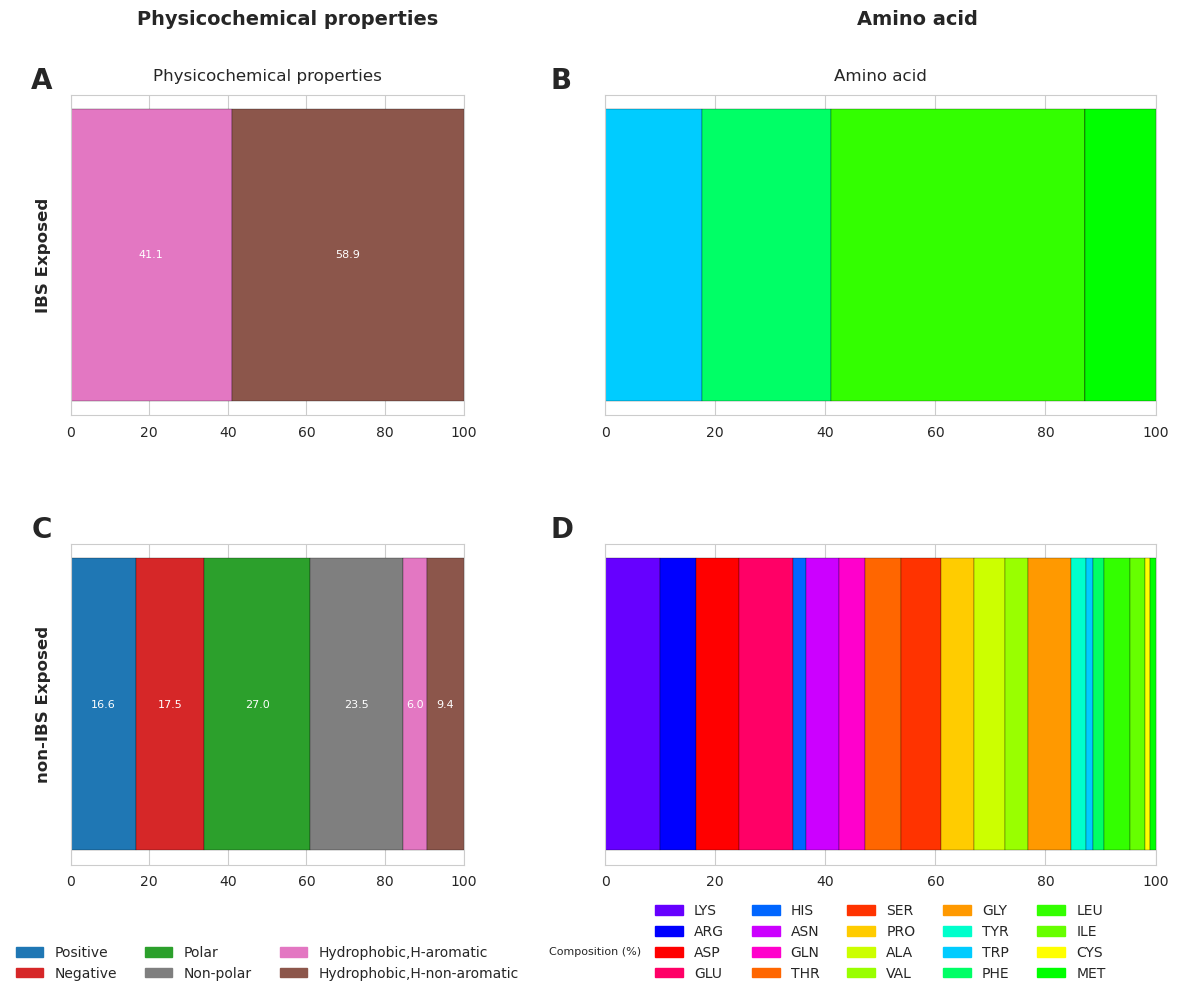

In [11]:
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

def make_predicted_composition_series(df, label_col, exposed_col, group_col):
    """
    Returns a pd.Series of percent composition of `group_col` within
    rows where label_col==1 and exposed_col==1 (and likewise for label_col==0).
    """
    # IBS Exposed
    s1 = (
        df.query(f"{label_col} == 1 and {exposed_col} == 1")
          [group_col]
          .value_counts(normalize=True)
          * 100
    )
    # non-IBS Exposed
    s0 = (
        df.query(f"{label_col} == 0 and {exposed_col} == 1")
          [group_col]
          .value_counts(normalize=True)
          * 100
    )
    return s1, s0

def plot_figure_2(df_test_pred):
    # 1) Build the four composition Series
    phys_ibs, phys_no  = make_predicted_composition_series(
        df_test_pred, 'IBS_pred', 'exposed', 'type_str'
    )
    aa_ibs,   aa_no    = make_predicted_composition_series(
        df_test_pred, 'IBS_pred', 'exposed', 'residue_str'
    )

    # 2) Define ordering & colors
    phys_order = [
        "Positive","Negative","Polar","Non-polar",
        "Hydrophobic,H-aromatic","Hydrophobic,H-non-aromatic"
    ]
    aa_order = [
        "LYS","ARG","ASP","GLU","HIS","ASN","GLN","THR","SER",
        "PRO","ALA","VAL","GLY","TYR","TRP","PHE","LEU","ILE","CYS","MET"
    ]

    phys_ibs = phys_ibs.reindex(phys_order, fill_value=0)
    phys_no  = phys_no.reindex(phys_order, fill_value=0)
    aa_ibs   = aa_ibs.reindex(aa_order, fill_value=0)
    aa_no    = aa_no.reindex(aa_order, fill_value=0)

    phys_colors = [colorsPerType[t] for t in phys_order]
    aa_colors   = [COLORS_taylor[a] for a in aa_order]

    # 3) Create subplots
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2,
        width_ratios=[1,1.4],
        height_ratios=[1,1],
        wspace=0.3, hspace=0.4
    )
    axA = fig.add_subplot(gs[0,0])
    axB = fig.add_subplot(gs[0,1])
    axC = fig.add_subplot(gs[1,0])
    axD = fig.add_subplot(gs[1,1])

    # 4) Helper to draw a single 100%-stacked bar in ax
    def draw_stack(grp, colors, ax, annotate=True):
        left = 0
        for pct, col in zip(grp.values, colors):
            ax.barh(0, pct, left=left, color=col, edgecolor="k", linewidth=0.2)
            if annotate and pct>0:
                ax.text(left + pct/2, 0,
                        f"{pct:.1f}",
                        ha="center", va="center",
                        color="white" if pct>5 else "black",
                        fontsize=8)
            left += pct
        ax.set_xlim(0,100)
        ax.set_yticks([])

    # Panel A: phys-chem IBS
    draw_stack(phys_ibs, phys_colors, axA)
    axA.set_title("Physicochemical properties", pad=10)
    axA.text(-0.1,1.02,"A", transform=axA.transAxes,
             fontsize=20, fontweight="bold")
    axA.text(-0.07,0.5,"IBS Exposed", transform=axA.transAxes,
             rotation=90, ha="center", va="center",
             fontsize=12, fontweight="bold")

    # Panel C: phys-chem non-IBS
    draw_stack(phys_no, phys_colors, axC)
    axC.text(-0.1,1.02,"C", transform=axC.transAxes,
             fontsize=20, fontweight="bold")
    axC.text(-0.07,0.5,"non-IBS Exposed", transform=axC.transAxes,
             rotation=90, ha="center", va="center",
             fontsize=12, fontweight="bold")

    # Phys-chem legend under left plots
    handles = [plt.Rectangle((0,0),1,1,color=c) for c in phys_colors]
    axC.legend(handles, phys_order,
               loc="lower center", bbox_to_anchor=(0.5,-0.4),
               ncol=3, frameon=False, title="")

    # Panel B: amino-acid IBS
    draw_stack(aa_ibs, aa_colors, axB, annotate=False)
    axB.set_title("Amino acid", pad=10)
    axB.text(-0.1,1.02,"B", transform=axB.transAxes,
             fontsize=20, fontweight="bold")

    # Panel D: amino-acid non-IBS
    draw_stack(aa_no, aa_colors, axD, annotate=False)
    axD.text(-0.1,1.02,"D", transform=axD.transAxes,
             fontsize=20, fontweight="bold")

    # Amino-acid legend under right plots
    handles = [plt.Rectangle((0,0),1,1,color=c) for c in aa_colors]
    axD.legend(handles, aa_order,
               loc="lower center", bbox_to_anchor=(0.5,-0.4),
               ncol=5, frameon=False, title="")

    # Shared x-label and column titles
    fig.text(0.5,0.02,"Composition (%)", ha="center", fontsize=8)
    fig.text(0.28,0.95,"Physicochemical properties",
             ha="center", fontsize=14, weight="bold")
    fig.text(0.73,0.95,"Amino acid", ha="center",
             fontsize=14, weight="bold")

    plt.show()

# Finally, call it:
plot_figure_2(df_predicted)
